# Example of PTV using data from the ADiHSRL
In this example, I will demonstrate a use case for how PTV, with the additional features to be developed in the SUPER project, can be used to denoise and process real lidar data. Utility libraries developed by NCAR for working with Adi/MPD data will be used to load in the data and perform preprocessing. A SPIRAL problem will be set up with this data, and a simple forward model for the molecular backscatter will be implemented.

# Imports and Setup

In [1]:
# General python environment imports
import sys, os, importlib
import torch
import numpy as np
import xarray as xr
import datetime
import matplotlib.pyplot as plt
import yaml
import time
from scipy.interpolate import  interp1d

In [2]:
# Set variables for some important paths
spiral_path = "/glade/u/home/bgarby/projects/SpiralTorch/python"
if spiral_path not in sys.path:
    sys.path.append(spiral_path)

# NCAR utils for loading and working with data
ncar_utils_path = "/glade/u/home/bgarby/projects/NCAR-LidarProcessing/libraries"
if ncar_utils_path not in sys.path:
    sys.path.append(ncar_utils_path)

# Other important paths to define
adi_data_path = "/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/" # You will need to set up a data directory mirroring one on the EOL linux share yourself if on Casper
cal_val_path = "/glade/u/home/bgarby/projects/eol-lidar-calvals/"

In [3]:
# SpiralTorch imports
from SpiralTorch import spiral
from SpiralTorch import loss
from SpiralTorch import fista
# NCAR-LidarProcessing utils
import xarray_utils.mpd_utils as mpd
import xarray_utils.cal_utils as cal

In [4]:
# Import for custom SpiralTorch cuda kernel if on GPU with the right environment
import STCuda

We will explicitly set the noise model here as well. In SpiralTorch, there are several different physical loss models representing effects like background and detector deadtime

In [5]:
loss_model = 'deadtime_bg' # bg refers to background

Check the PyTorch environment - did we detect a GPU?

In [6]:
is_cuda = torch.cuda.is_available()
device = torch.device(torch.cuda.current_device()) if is_cuda else torch.device("cpu")
dtype = torch.float64 # Consider changing to float32..
# device = torch.device("cpu")

if is_cuda:
    torch.backends.cudnn.benchmark = True

print(f'Preparing to use device {device}')
print(f"Current device name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
print(f'Torch version: {torch.__version__}')

Preparing to use device cuda:0
Current device name: Tesla V100-SXM2-32GB
Torch version: 2.8.0+cu129


# Load in Lidar Data and Preprocess

In [7]:
# Set parameters for dataloader
start_time = datetime.datetime(2025,9,4,0)
stop_time = datetime.datetime(2025,9,5,0)
MPDnumber=6 # 6 is for the ADiHSRL
time_res=1.*60
channel_request = ['HSRLMolecular','HSRLCombined'] #, 'HSRLMolecularLow', 'HSRLCombinedLow']
device_list = ['MCS','WS','LL','Etalon', 'HKeep']
extra_cal_fields = ['Overlap_PTV_File', 'Diff_Geo_PTV_File']
cal_file = cal_val_path+'calvals/dial%d_calvals.json'%MPDnumber

In [8]:
raw_mcs_ds_lst = mpd.load_dataset(start_time,
                              stop_time,
                              MPDnumber,
                              time_res,
                              channel_request,
                              thin_num=2,
                              repeat_thin=1,
                              random_thin=False,
                              basepath=adi_data_path,
                              cal_path=cal_val_path,
                              device_list=device_list,
                              deadtime_correct=False,
                              afterpulse_correct=False,
                              deadtime_correct_raw=True,
                              count_rate_threshold=5e6,
                              range_bin_int=1,
                              verbose=True
                              )


No entry for Alt_Angle found
No entry for Az_Angle found
No entry for Pulse_File found
Found no files matching MCS*.nc in folder
/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250905/
Loading Sep 04, 2025, 00:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_000000.nc]
Loading Sep 04, 2025, 01:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_010000.nc]
Loading Sep 04, 2025, 02:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_020000.nc]


/glade/u/home/bgarby/projects/NCAR-LidarProcessing/libraries/xarray_utils/mpd_utils.py:560: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  load_ds = xr.concat([load_ds, ds0], dim='time')


Loading Sep 04, 2025, 03:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_030000.nc]
Loading Sep 04, 2025, 04:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_040000.nc]
Loading Sep 04, 2025, 05:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_050000.nc]
Loading Sep 04, 2025, 06:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_060000.nc]
Loading Sep 04, 2025, 07:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_070000.nc]
Loading Sep 04, 2025, 08:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_080000.nc]
Loading Sep 04, 2025, 09:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/MCS_06_20250904_090000.nc]
Loading Sep 04, 2025, 10:00:00
[/glade/derecho/scratch/bgarby/tmp/raw

/glade/u/home/bgarby/projects/NCAR-LidarProcessing/libraries/xarray_utils/mpd_utils.py:560: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  load_ds = xr.concat([load_ds, ds0], dim='time')


Loading Sep 04, 2025, 11:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/HKeep_06_20250904_110000.nc]
Loading Sep 04, 2025, 12:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/HKeep_06_20250904_120000.nc]
Loading Sep 04, 2025, 13:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/HKeep_06_20250904_130000.nc]
Loading Sep 04, 2025, 14:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/HKeep_06_20250904_140000.nc]
Loading Sep 04, 2025, 15:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/HKeep_06_20250904_150000.nc]
Loading Sep 04, 2025, 16:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/HKeep_06_20250904_160000.nc]
Loading Sep 04, 2025, 17:00:00
[/glade/derecho/scratch/bgarby/tmp/raw_mpd_data/adihsrl_data/2025/20250904/HKeep_06_20250904_170000.nc]
Loading Sep 04, 2025, 18:00:00
[/glade/derecho/scratch/

Some preprocessing tasks. We will estimate the background (solar noise and detector noise generally). We will get the detector active time. We will also set up the fit and validation dictionaries

In [9]:
raw_channels = [ch_req + '_Uncorr' for ch_req in channel_request]
range_max = 12000
background_lim_index = -50

In [10]:
mcs_ds_lst = []
for ds in raw_mcs_ds_lst:
    mpd.get_detector_active_time(ds)
    for cal_field in extra_cal_fields:
        mpd.get_cal(ds, cal_field, cal_file, fields=['value'])

    # Get background info
    bg_dct={}
    for ch_idx, ch in enumerate(channel_request):
        bg_dct[ch] = {}
        bg_dct[ch]['counts'] = np.sum(ds[raw_channels[ch_idx]].values[:,background_lim_index:],axis=1)/np.abs(background_lim_index)
        bg_dct[ch]['active_time'] = np.sum(ds[ch + "_ActiveTime"].values[:,background_lim_index:],axis=1)/np.abs(background_lim_index)
        # Ensure active time is always valid
        nan_idx = np.where((bg_dct[ch]['active_time'] == 0) | np.isnan(bg_dct[ch]['active_time']))
        bg_dct[ch]['active_time'][nan_idx] = 1.0
        bg_dct[ch]['rate'] = bg_dct[ch]['counts']/bg_dct[ch]['active_time']
        for bg_data in bg_dct[ch]:
            ds['bg_'+ch+'_'+bg_data] = xr.DataArray(bg_dct[ch][bg_data],dims=('time'),coords={'time':ds['time']},)

    # Trim in range
    mcs_ds_lst.append(ds.sel(range=slice(0,range_max)))

In [11]:
image_shape = (len(mcs_ds_lst[0]['time']), len(mcs_ds_lst[0]['range']))
loss_model_inputs = loss.noise_model_dct[loss_model]['noise_model_inputs'] + loss.noise_model_dct[loss_model]['noise_optional'] + loss.noise_model_dct[loss_model]['fixed_optional']

fit_dct_lst = []
val_dct_lst = []
for ch_idx, ch in enumerate(channel_request):
    # Initialize the data dicts
    fit_dct = {}
    val_dct = {}

    # Photon count data
    fit_dct['counts'] = mcs_ds_lst[0][raw_channels[ch_idx]].values
    val_dct['counts'] = mcs_ds_lst[1][raw_channels[ch_idx]].values

    # Active time (only required for deadtime loss models)
    if 'active_time' in loss_model_inputs:
        fit_dct['active_time'] = mcs_ds_lst[0][ch + "_ActiveTime"].values
        val_dct['active_time'] = mcs_ds_lst[1][ch + "_ActiveTime"].values

    # Background (only required for background loss models (bg in name))
    if 'bg' in loss_model_inputs:
        if 'poisson' in loss_model:
            fit_dct['bg'] = mcs_ds_lst[0]['bg_'+ ch +'_counts'].values[:,np.newaxis]
            val_dct['bg'] = mcs_ds_lst[1]['bg_'+ ch +'_counts'].values[:,np.newaxis]
        else:
            fit_dct['bg'] = mcs_ds_lst[0]['bg_'+ ch +'_rate'].values[:,np.newaxis]
            val_dct['bg'] = mcs_ds_lst[1]['bg_'+ ch +'_rate'].values[:,np.newaxis]

    # Append to the lists
    fit_dct_lst.append(fit_dct)
    val_dct_lst.append(val_dct)

In [12]:
# Add a mask/weighting scheme if you wish. I will do a simple range mask here
range_min = 300
range_max = 10000

global_mask = ((mcs_ds_lst[0]['range'].values > range_min) & (mcs_ds_lst[0]['range'].values < range_max)).astype(float)[None,:] * np.ones(image_shape)

for ch_idx, ch in enumerate(channel_request):
    if 'channel_mask' in loss_model_inputs:
        fit_dct_lst[ch_idx]['channel_mask'] = global_mask
        val_dct_lst[ch_idx]['channel_mask'] = global_mask

# Create a Basic HSRL Forward Model

In [13]:
# Lidar equation values
range_arr = mcs_ds_lst[0]['range'].values
dr = torch.tensor(np.concatenate([range_arr[:1],np.diff(range_arr)]), device=device, dtype=dtype)
if len(dr.shape) < 2:
    dr_2d = dr.unsqueeze(0)
else:
    dr_2d = dr
r2_loss = torch.tensor(1.0/range_arr**2, device=device, dtype=dtype)
c_mm = .5
c_mc = .9

In [14]:
# Physical constants needed for this section
from scipy.constants import c, g, R, Avogadro, Boltzmann
Mair = 28.97 # (g/mol) molar mass of air (dry)
kBatm = Boltzmann*9.86923e-6

In [15]:
# Molecular backscatter
temperature_lapse_rate = -9.0*(1e-3) # Kelvin/m
atm_to_pa = 101325
wavelength = 780.24e-9

# Thermo data from ground station
temperature_1d = torch.tensor(mcs_ds_lst[0]['Surface_Temperature'].values.squeeze().reshape(-1,1), device=device, dtype=dtype)
pressure_1d = torch.tensor(mcs_ds_lst[0]['Surface_Pressure'].values.squeeze().reshape(-1,1), device=device, dtype=dtype)
temperature = torch.cumsum(temperature_lapse_rate * dr.view(1,-1), 1) + temperature_1d
ext = g*Mair/(R*temperature)
pressure = pressure_1d*torch.exp(-1e-3*(torch.cumsum(dr[None,...]*ext,axis=1)))

# Now calculate the backscatter and extinction coefficients
molecular_backscatter = 5.45*(((550.0e-9)/wavelength)**4)*(1e-32)*(pressure*101325/(temperature*Boltzmann))
molecular_extinction = 8*np.pi/3 * molecular_backscatter

In [16]:
def molecular_fwd_model(**x):
    """
    forward model for molecular channel
    
    expects x['gain'] - channel gain
            x['extinction'] - the extinction of light in the atmosphere
            x['overlap'] - the overlap function
    returns 
            fwd_mod['y_mean_est']
    """
    fwd_mod = {
        'y_mean_est': torch.exp(x['gain']) * torch.exp(x['overlap']) * r2_loss * (c_mm * molecular_backscatter) * torch.exp(-x['extinction']) * torch.exp(-2 * torch.cumsum(molecular_extinction * dr_2d,1))
    }
    return fwd_mod

def combined_fwd_model(**x):
    """
    forward model for combined channel
    
    expects x['gain_combined'] - channel gain
            x['backscatter'] - the cloud and aerosol backscatter
            x['extinction'] - the extinction of light in the atmosphere
            x['overlap'] - the overlap function
    returns 
            fwd_mod['y_mean_est']
    """
    fwd_mod = {
        'y_mean_est': torch.exp(x['gain_combined']) * torch.exp(x['overlap']) * r2_loss * (c_mc * molecular_backscatter + torch.exp(x['backscatter'])) * torch.exp(-x['extinction']) * torch.exp(-2 * torch.cumsum(molecular_extinction * dr_2d,1))
    }
    return fwd_mod

In [17]:
# Estimate an overlap function
overlap_file = os.path.join(cal_val_path, 'calfiles', mcs_ds_lst[0].attrs.get('Overlap_PTV_File',None))

# Load overlap data
overlap_data = np.load(overlap_file)

# Trim/scale low altitudes
low_tol=1e-3
low_interp_lim=1e-5
if low_tol > overlap_data[0,1]:
    range_trim = overlap_data[overlap_data[:,1] < low_tol, 0]
    overlap_last_val = overlap_data[overlap_data[:,1] < low_tol, 1][-1]
    if low_interp_lim > overlap_last_val:
        overlap_data[overlap_data[:,1] < low_tol, 1] = overlap_last_val
    else:
        overlap_near = low_interp_lim + ((range_trim - range_trim[0])**2) * (overlap_last_val - low_interp_lim) / ((range_trim[-1] - range_trim[0])**2)
        overlap_data[overlap_data[:,1] < low_tol, 1] = overlap_near

# Interpolate and correct dimensions
overlap_interp = interp1d(overlap_data[:,0], overlap_data[:,1],bounds_error=False,fill_value='extrapolate',kind='linear')
overlap_model = overlap_interp(range_arr)
overlap_init = torch.tensor(np.abs(overlap_model[None,:] * np.ones([1,len(range_arr)])) + 1e-10, device=device, dtype=dtype)

# Set up the SPIRAL Problem

In [44]:
fista_ver_str = 'cuda-fista'  # 'cuda-fista', 'jit-fista'

In [45]:
# Start with just the molecular channel...
fwd_model_lst = [molecular_fwd_model] # , combined_fwd_model]

# If you are just using molecular (recommended to start...)
y_fit_dct_lst = [fit_dct_lst[0]]
y_val_dct_lst = [val_dct_lst[0]]

In [46]:
# create spiral optimization object
spiral_opt = spiral.multiSpiral_autograd(device, dtype, valid_mean=10)
spiral_opt.set_fista_version(fista_ver_str)
spiral_opt.set_fwd_model_lst(fwd_model_lst)
spiral_opt.set_y_fit_lst(y_fit_dct_lst)
spiral_opt.set_y_val_lst(y_val_dct_lst)
spiral_opt.set_noise_model([loss_model]*len(fwd_model_lst))

In [47]:
# check for alignment between observations and the noise model inputs
pass_test_bool, out_text, = spiral_opt.check_noise_model_inputs()
print(f"Check passed: {pass_test_bool}\n")
print(out_text)

Check passed: True

fit data is does not have a dictionary entry for optional input channel_weight in channel 0
validation data is does not have a dictionary entry for optional input channel_weight in channel 0



In [48]:
# set the initial conditions
gain_mol0 = 1e16
gain_comb0 = 1e16
overlap0 = overlap_init.detach().cpu().numpy() # Or just np.ones((1,len(range_arr)))

x0 = {
    'gain': np.log(gain_mol0)*np.ones([1]*len(image_shape)),
    'gain_combined': np.log(gain_comb0)*np.ones([1]*len(image_shape)),
    'overlap': np.log(overlap0),
    'backscatter': np.log(1e-7 * np.ones(image_shape)),
    'extinction': np.log(np.ones(image_shape))
}
x0_tnsr = {x0_key: torch.tensor(x0_data, device=device, dtype=dtype) for x0_key,x0_data in x0.items()}

In [56]:
sparsa_subprob_config_dct = {
    # As scalars, these don't matter as much in theory
    'gain':{
        'alpha_min':1e9,
        'alpha_max':1e20,
        'alpha':1e9,
    },
    'gain_combined':{
        'alpha_min':1e4,
        'alpha_max':1e20,
        'alpha':1,
    },
    'extinction':{
        'alpha_min':1e4,
        'alpha_max':1e20,
        'alpha':1,
    },
    'backscatter':{
        'alpha_min':1e4,
        'alpha_max':1e20,
        'alpha':1,
    },
    'overlap':{
        'alpha_min':1e4,
        'alpha_max':1e20,
        'alpha':1,
    }
    }

In [57]:
spiral_opt.set_estimate_lst(['gain'])

# this is where the subproblems for each variable get created, so there needs to be an entry for each
spiral_opt.add_sparsa_config(sparsa_subprob_config_dct)
spiral_opt.set_initial_conditions(x0)
spiral_opt.set_tv_penalties({'gain':1e0,'extinction':1e1})  # this must happen after the subproblem is defined
spiral_opt.verbose = True

In [58]:
spiral_opt.solve()

iteration 0
solving for gain
Step: 0.012051960711795283
Loss: -8.388308e+08
alpha: 1000000000.0
subproblem iterations: 100
Maximum Iterations Exceeded. Final step: 0.00012563312179961181

iteration 1
solving for gain
Step: 0.012923006657115255
Loss: -8.411532e+08
alpha: 1000000000.0
subproblem iterations: 100
Maximum Iterations Exceeded. Final step: 0.00012879140037613853

iteration 2
solving for gain
Step: 0.012364472329901788
Loss: -8.433351e+08
alpha: 1000000000.0
subproblem iterations: 100
Maximum Iterations Exceeded. Final step: 0.00011357791022175726

iteration 3
solving for gain
Step: 0.00981296651465976
Loss: -8.447539e+08
alpha: 1000000000.0
subproblem iterations: 100
Maximum Iterations Exceeded. Final step: 7.998693318414708e-05

iteration 4
solving for gain
Step: 0.0061441672312621395
Loss: -8.453309e+08
alpha: 1000000000.0
subproblem iterations: 100
Maximum Iterations Exceeded. Final step: 4.4140086258111535e-05

iteration 5
solving for gain
Step: 0.0030972808447465184
Loss

'Optimization Successful after 44 iterations'

In [63]:
x_sol = spiral_opt.get_x()
vld_loss = spiral_opt.valid_loss()
print(f"Validation Loss: {vld_loss}")

Validation Loss: -845477747.4125687


In [64]:
yt = molecular_fwd_model(**x0_tnsr)
yf = molecular_fwd_model(**spiral_opt.x)

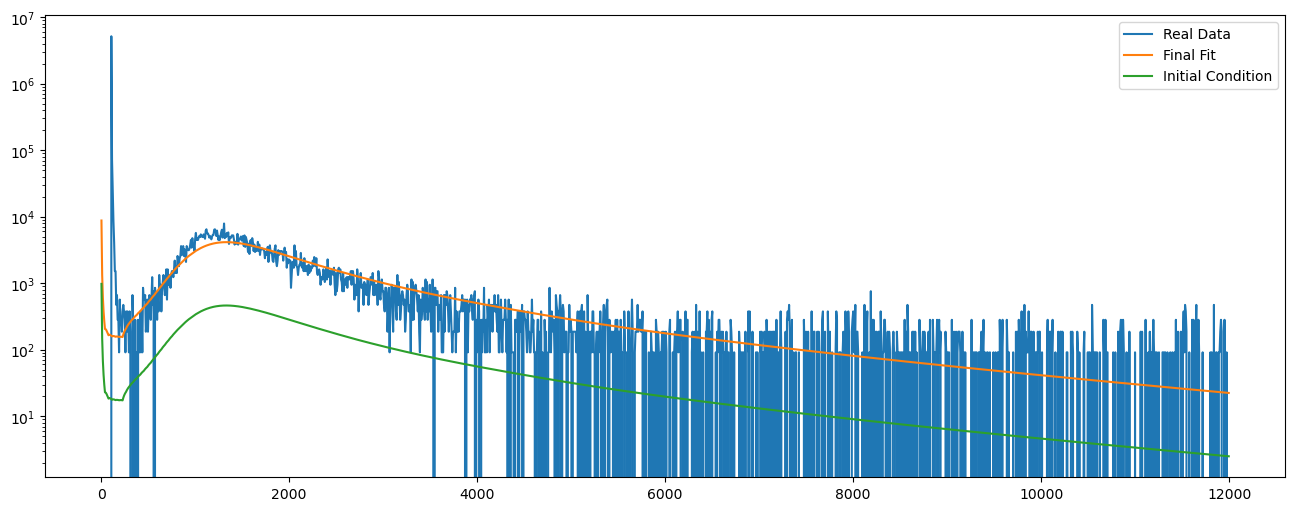

In [68]:
iplot=100
di_plot = 200
plt.figure(figsize=(16,6))
plt.plot(range_arr, (y_fit_dct_lst[0]['counts']/y_fit_dct_lst[0]['active_time'])[iplot,:] - y_fit_dct_lst[0]['bg'][iplot,0],label='Real Data')
plt.plot(range_arr, yf['y_mean_est'].detach().cpu().numpy()[iplot,:],label='Final Fit')
plt.plot(range_arr, yt['y_mean_est'].detach().cpu().numpy()[iplot,:],label='Initial Condition')
plt.legend()
plt.yscale('log')

# Plot calls for other loss models (ie poisson, poisson_bg)
#plt.plot(range_arr, (y_fit_dct_lst[0]['counts']/y_fit_dct_lst[0]['active_time'])[iplot,:],label='Deadtime Rate Data')
#plt.plot(range_arr, (y_fit_dct_lst[0]['counts'])[::di_plot,:].T,label='Poisson Data')
#plt.plot(range_arr, (y_fit_dct_lst[0]['counts'] - y_fit_dct_lst[0]['bg'])[iplot,:].T,label='Poisson, no BG, Data')

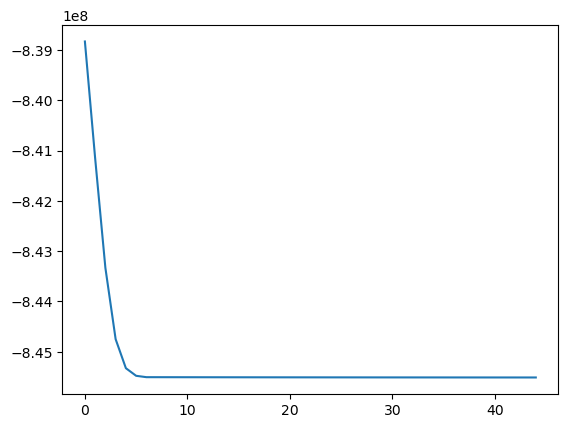

In [66]:
plt.plot(spiral_opt.loss_lst)